### Importations des librairies 

In [3]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

### Lecture des fichiers 

* Découvrons le jeu de donnée bureau qui represente les crédits des clients dans les autres institutions financières

In [4]:
bureau = pd.read_csv('../Dataset/bureau.csv')
bureau.head()

,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,NaN,0.0,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,NaN,0.0,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.5,NaN,NaN,0.0,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.0,NaN,NaN,0.0,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.0,NaN,NaN,0.0,Consumer credit,-21,NaN


### Analysons quelques informations sur ce jeu de donnée

In [5]:
print('EDA de bureau')
print(f'Le jeu de donnée contient :{bureau.shape[0]} lignes et {bureau.shape[1]} colonnes ')
print(f'Le jeu de donnée contient {bureau.duplicated().sum()} doublon')
print(f'--------------------------------------------------------------------------------------')
print(f"Le jeu de donnée contient {bureau.isnull().sum()} valeurs manqantes")
print(f'--------------------------------------------------------------------------------------')
print(f'Le pourcentage de valeurs manquantes de chaque colonne est de : {bureau.isnull().sum()*100}')

EDA de bureau
Le jeu de donnée contient :1716428 lignes et 17 colonnes 
Le jeu de donnée contient 0 doublon
--------------------------------------------------------------------------------------
Le jeu de donnée contient SK_ID_CURR                      0
SK_ID_BUREAU                    0
CREDIT_ACTIVE                   0
CREDIT_CURRENCY                 0
DAYS_CREDIT                     0
CREDIT_DAY_OVERDUE              0
DAYS_CREDIT_ENDDATE        105553
DAYS_ENDDATE_FACT          633653
AMT_CREDIT_MAX_OVERDUE    1124488
CNT_CREDIT_PROLONG              0
AMT_CREDIT_SUM                 13
AMT_CREDIT_SUM_DEBT        257669
AMT_CREDIT_SUM_LIMIT       591780
AMT_CREDIT_SUM_OVERDUE          0
CREDIT_TYPE                     0
DAYS_CREDIT_UPDATE              0
AMT_ANNUITY               1226791
dtype: int64 valeurs manqantes
--------------------------------------------------------------------------------------
Le pourcentage de valeurs manquantes de chaque colonne est de : SK_ID_CURR         

* Dans ce jeu de donnée nous allons nous concentrer sur quelques colonnes qui nous seront utiles pour la fusion de notre de donnée finale

In [6]:
bureau.info()

<class 'pandas.DataFrame'>
RangeIndex: 1716428 entries, 0 to 1716427
Data columns (total 17 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   SK_ID_CURR              int64  
 1   SK_ID_BUREAU            int64  
 2   CREDIT_ACTIVE           str    
 3   CREDIT_CURRENCY         str    
 4   DAYS_CREDIT             int64  
 5   CREDIT_DAY_OVERDUE      int64  
 6   DAYS_CREDIT_ENDDATE     float64
 7   DAYS_ENDDATE_FACT       float64
 8   AMT_CREDIT_MAX_OVERDUE  float64
 9   CNT_CREDIT_PROLONG      int64  
 10  AMT_CREDIT_SUM          float64
 11  AMT_CREDIT_SUM_DEBT     float64
 12  AMT_CREDIT_SUM_LIMIT    float64
 13  AMT_CREDIT_SUM_OVERDUE  float64
 14  CREDIT_TYPE             str    
 15  DAYS_CREDIT_UPDATE      int64  
 16  AMT_ANNUITY             float64
dtypes: float64(8), int64(6), str(3)
memory usage: 222.6 MB


In [7]:
bureau.columns

Index(['SK_ID_CURR', 'SK_ID_BUREAU', 'CREDIT_ACTIVE', 'CREDIT_CURRENCY',
       'DAYS_CREDIT', 'CREDIT_DAY_OVERDUE', 'DAYS_CREDIT_ENDDATE',
       'DAYS_ENDDATE_FACT', 'AMT_CREDIT_MAX_OVERDUE', 'CNT_CREDIT_PROLONG',
       'AMT_CREDIT_SUM', 'AMT_CREDIT_SUM_DEBT', 'AMT_CREDIT_SUM_LIMIT',
       'AMT_CREDIT_SUM_OVERDUE', 'CREDIT_TYPE', 'DAYS_CREDIT_UPDATE',
       'AMT_ANNUITY'],
      dtype='str')

* Choix des colonnes 

In [8]:
## Aggregation des données
bureau_agg = bureau.groupby("SK_ID_CURR").agg({
    
    'DAYS_CREDIT': ['min', 'max', 'mean', 'var'],
    'DAYS_CREDIT_ENDDATE': ['min', 'max', 'mean'],
    'DAYS_CREDIT_UPDATE': ['mean'],
    'CREDIT_DAY_OVERDUE': ['max', 'mean'],
    'AMT_CREDIT_MAX_OVERDUE': ['mean'],
    'AMT_CREDIT_SUM': ['max', 'mean', 'sum'],
    'AMT_CREDIT_SUM_DEBT': ['max', 'mean', 'sum'],
    'AMT_CREDIT_SUM_OVERDUE': ['mean'],
    'AMT_CREDIT_SUM_LIMIT': ['mean', 'sum'],
    'AMT_ANNUITY': ['max', 'mean'],
})
bureau_agg.columns = [
    "BUREAU_" + "_".join(col)
    for col in bureau_agg.columns
]

bureau_agg = bureau_agg.reset_index()

In [9]:
bureau

,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.00,0.0,NaN,0.0,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.00,171342.0,NaN,0.0,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.50,NaN,NaN,0.0,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.00,NaN,NaN,0.0,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.00,NaN,NaN,0.0,Consumer credit,-21,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1716423,259355,5057750,Active,currency 1,-44,0,-30.0,NaN,0.0,0,11250.00,11250.0,0.0,0.0,Microloan,-19,NaN
1716424,100044,5057754,Closed,currency 1,-2648,0,-2433.0,-2493.0,5476.5,0,38130.84,0.0,0.0,0.0,Consumer credit,-2493,NaN
1716425,100044,5057762,Closed,currency 1,-1809,0,-1628.0,-970.0,NaN,0,15570.00,NaN,NaN,0.0,Consumer credit,-967,NaN
1716426,246829,5057770,Closed,currency 1,-1878,0,-1513.0,-1513.0,NaN,0,36000.00,0.0,0.0,0.0,Consumer credit,-1508,NaN


* Conclusion 

* Decouvrons le jeu de donnée bureau_balance qui represente la donnée du mois concernant les crédits dans bureau

In [10]:
bureau_b = pd.read_csv('../Dataset/bureau_balance.csv')
bureau_b.head()

,SK_ID_BUREAU,MONTHS_BALANCE,STATUS
0,5715448,0,C
1,5715448,-1,C
2,5715448,-2,C
3,5715448,-3,C
4,5715448,-4,C


In [11]:
print('EDA de bureau_b')
print(f'Le jeu de donnée contient :{bureau_b.shape[0]} lignes et {bureau_b.shape[1]} colonnes ')
print(f'Le jeu de donnée contient {bureau_b.duplicated().sum()} doublon')
print(f"Le jeu de donnée contient {bureau_b.isnull().sum()} valeurs manqantes")
print(f'Le pourcentage de valeurs manquantes de chaque colonne est de : {bureau_b.isnull().sum()*100}')

EDA de bureau_b
Le jeu de donnée contient :27299925 lignes et 3 colonnes 
Le jeu de donnée contient 0 doublon
Le jeu de donnée contient SK_ID_BUREAU      0
MONTHS_BALANCE    0
STATUS            0
dtype: int64 valeurs manqantes
Le pourcentage de valeurs manquantes de chaque colonne est de : SK_ID_BUREAU      0
MONTHS_BALANCE    0
STATUS            0
dtype: int64


* Donc le choix des features est connu dans ce jeu de donnée nous allons nous concentrer sur le mois dont nous prendrons des valeurs comme par exemple le min le max et la taille

In [12]:
bureau_balance_agg = bureau_b.groupby("SK_ID_BUREAU").agg({
    "MONTHS_BALANCE":["min","max","size"]
})
bureau_balance_agg.columns = [
    "BUREAU_BALANCE_" + "_".join(col)
    for col in bureau_balance_agg.columns
]

bureau_balance_agg = bureau_balance_agg.reset_index()

In [13]:
bureau_balance_agg

,SK_ID_BUREAU,BUREAU_BALANCE_MONTHS_BALANCE_min,BUREAU_BALANCE_MONTHS_BALANCE_max,BUREAU_BALANCE_MONTHS_BALANCE_size
0,5001709,-96,0,97
1,5001710,-82,0,83
2,5001711,-3,0,4
3,5001712,-18,0,19
4,5001713,-21,0,22
...,...,...,...,...
817390,6842884,-47,0,48
817391,6842885,-23,0,24
817392,6842886,-32,0,33
817393,6842887,-36,0,37


* joignons le jeu de donnée bureau avec bureau_b_agg

In [14]:
bureau = bureau.merge(
    bureau_balance_agg,
    on="SK_ID_BUREAU",
    how="left"
)

In [15]:
bureau.columns

Index(['SK_ID_CURR', 'SK_ID_BUREAU', 'CREDIT_ACTIVE', 'CREDIT_CURRENCY',
       'DAYS_CREDIT', 'CREDIT_DAY_OVERDUE', 'DAYS_CREDIT_ENDDATE',
       'DAYS_ENDDATE_FACT', 'AMT_CREDIT_MAX_OVERDUE', 'CNT_CREDIT_PROLONG',
       'AMT_CREDIT_SUM', 'AMT_CREDIT_SUM_DEBT', 'AMT_CREDIT_SUM_LIMIT',
       'AMT_CREDIT_SUM_OVERDUE', 'CREDIT_TYPE', 'DAYS_CREDIT_UPDATE',
       'AMT_ANNUITY', 'BUREAU_BALANCE_MONTHS_BALANCE_min',
       'BUREAU_BALANCE_MONTHS_BALANCE_max',
       'BUREAU_BALANCE_MONTHS_BALANCE_size'],
      dtype='str')

In [16]:
bureau_agg

,SK_ID_CURR,BUREAU_DAYS_CREDIT_min,BUREAU_DAYS_CREDIT_max,BUREAU_DAYS_CREDIT_mean,BUREAU_DAYS_CREDIT_var,BUREAU_DAYS_CREDIT_ENDDATE_min,BUREAU_DAYS_CREDIT_ENDDATE_max,BUREAU_DAYS_CREDIT_ENDDATE_mean,BUREAU_DAYS_CREDIT_UPDATE_mean,BUREAU_CREDIT_DAY_OVERDUE_max,...,BUREAU_AMT_CREDIT_SUM_mean,BUREAU_AMT_CREDIT_SUM_sum,BUREAU_AMT_CREDIT_SUM_DEBT_max,BUREAU_AMT_CREDIT_SUM_DEBT_mean,BUREAU_AMT_CREDIT_SUM_DEBT_sum,BUREAU_AMT_CREDIT_SUM_OVERDUE_mean,BUREAU_AMT_CREDIT_SUM_LIMIT_mean,BUREAU_AMT_CREDIT_SUM_LIMIT_sum,BUREAU_AMT_ANNUITY_max,BUREAU_AMT_ANNUITY_mean
0,100001,-1572,-49,-735.000000,240043.666667,-1329.0,1778.0,82.428571,-93.142857,0,...,2.076236e+05,1453365.000,373239.00,85240.928571,596686.500,0.0,0.00000,0.000,10822.5,3545.357143
1,100002,-1437,-103,-874.000000,186150.000000,-1072.0,780.0,-349.000000,-499.875000,0,...,1.081319e+05,865055.565,245781.00,49156.200000,245781.000,0.0,7997.14125,31988.565,0.0,0.000000
2,100003,-2586,-606,-1400.750000,827783.583333,-2434.0,1216.0,-544.500000,-816.000000,0,...,2.543501e+05,1017400.500,0.00,0.000000,0.000,0.0,202500.00000,810000.000,NaN,NaN
3,100004,-1326,-408,-867.000000,421362.000000,-595.0,-382.0,-488.500000,-532.000000,0,...,9.451890e+04,189037.800,0.00,0.000000,0.000,0.0,0.00000,0.000,NaN,NaN
4,100005,-373,-62,-190.666667,26340.333333,-128.0,1324.0,439.333333,-54.333333,0,...,2.190420e+05,657126.000,543087.00,189469.500000,568408.500,0.0,0.00000,0.000,4261.5,1420.500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
305806,456249,-2713,-483,-1667.076923,407302.243590,-2499.0,1363.0,-1232.333333,-1064.538462,0,...,2.841430e+05,3693858.660,163071.00,16307.100000,163071.000,0.0,0.00000,0.000,NaN,NaN
305807,456250,-1002,-760,-862.000000,15724.000000,-272.0,2340.0,1288.333333,-60.333333,0,...,1.028820e+06,3086459.550,1840308.48,744013.365000,2232040.095,0.0,19422.79500,58268.385,384147.0,154567.965000
305808,456253,-919,-713,-867.500000,10609.000000,-189.0,1113.0,280.500000,-253.250000,0,...,9.900000e+05,3960000.000,1624797.00,448958.250000,1795833.000,0.0,0.00000,0.000,58369.5,58369.500000
305809,456254,-1104,-1104,-1104.000000,NaN,-859.0,-859.0,-859.000000,-401.000000,0,...,4.500000e+04,45000.000,0.00,0.000000,0.000,0.0,NaN,0.000,0.0,0.000000


* Conclusion 

* Decouvrons le jeu de donnée previous_app 

In [17]:
prev_app = pd.read_csv('../Dataset/previous_application.csv')
prev_app.head()

,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,...,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,2030495,271877,Consumer loans,1730.430,17145.0,17145.0,0.0,17145.0,SATURDAY,15,...,Connectivity,12.0,middle,POS mobile with interest,365243.0,-42.0,300.0,-42.0,-37.0,0.0
1,2802425,108129,Cash loans,25188.615,607500.0,679671.0,NaN,607500.0,THURSDAY,11,...,XNA,36.0,low_action,Cash X-Sell: low,365243.0,-134.0,916.0,365243.0,365243.0,1.0
2,2523466,122040,Cash loans,15060.735,112500.0,136444.5,NaN,112500.0,TUESDAY,11,...,XNA,12.0,high,Cash X-Sell: high,365243.0,-271.0,59.0,365243.0,365243.0,1.0
3,2819243,176158,Cash loans,47041.335,450000.0,470790.0,NaN,450000.0,MONDAY,7,...,XNA,12.0,middle,Cash X-Sell: middle,365243.0,-482.0,-152.0,-182.0,-177.0,1.0
4,1784265,202054,Cash loans,31924.395,337500.0,404055.0,NaN,337500.0,THURSDAY,9,...,XNA,24.0,high,Cash Street: high,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
print('EDA de prev_app')
print(f'Le jeu de donnée contient :{prev_app.shape[0]} lignes et {prev_app.shape[1]} colonnes ')
print('---------------------------------------------------------')
print(f'Le jeu de donnée contient {prev_app.duplicated().sum()} doublon')

print(f"Le jeu de donnée contient {prev_app.isnull().sum()} valeurs manqantes")
print('-----------------------------------------------------------------')
print(f'Le pourcentage de valeurs manquantes de chaque colonne est de : {prev_app.isnull().sum()*100}')

EDA de prev_app
Le jeu de donnée contient :1670214 lignes et 37 colonnes 
---------------------------------------------------------
Le jeu de donnée contient 0 doublon
Le jeu de donnée contient SK_ID_PREV                           0
SK_ID_CURR                           0
NAME_CONTRACT_TYPE                   0
AMT_ANNUITY                     372235
AMT_APPLICATION                      0
AMT_CREDIT                           1
AMT_DOWN_PAYMENT                895844
AMT_GOODS_PRICE                 385515
WEEKDAY_APPR_PROCESS_START           0
HOUR_APPR_PROCESS_START              0
FLAG_LAST_APPL_PER_CONTRACT          0
NFLAG_LAST_APPL_IN_DAY               0
RATE_DOWN_PAYMENT               895844
RATE_INTEREST_PRIMARY          1664263
RATE_INTEREST_PRIVILEGED       1664263
NAME_CASH_LOAN_PURPOSE               0
NAME_CONTRACT_STATUS                 0
DAYS_DECISION                        0
NAME_PAYMENT_TYPE                    0
CODE_REJECT_REASON                   0
NAME_TYPE_SUITE           

* Concernant le choix des colonnes nous allons prendre 

In [19]:
previous_agg = prev_app.groupby("SK_ID_CURR").agg({
    "AMT_APPLICATION": ["mean", "max"],
    "AMT_CREDIT": ["mean", "sum"],
    "CNT_PAYMENT": ["mean", "max"]
})

previous_agg.columns = [
    "PREV_" + "_".join(col)
    for col in previous_agg.columns
]

previous_agg = previous_agg.reset_index()

* Conclusion

* Decouvrons le jeu de donnée posh_cash

In [20]:
pos_cash = pd.read_csv('../Dataset/POS_CASH_balance.csv')
pos_cash.head()

,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,CNT_INSTALMENT,CNT_INSTALMENT_FUTURE,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
0,1803195,182943,-31,48.0,45.0,Active,0,0
1,1715348,367990,-33,36.0,35.0,Active,0,0
2,1784872,397406,-32,12.0,9.0,Active,0,0
3,1903291,269225,-35,48.0,42.0,Active,0,0
4,2341044,334279,-35,36.0,35.0,Active,0,0


In [21]:
print('EDA de pos_cash')
print(f'Le jeu de donnée contient :{pos_cash.shape[0]} lignes et {pos_cash.shape[1]} colonnes ')
print('---------------------------------------------------------')
print(f'Le jeu de donnée contient {pos_cash.duplicated().sum()} doublon')

print(f"Le jeu de donnée contient {pos_cash.isnull().sum()} valeurs manqantes")
print('-----------------------------------------------------------------')
print(f'Le pourcentage de valeurs manquantes de chaque colonne est de : {pos_cash.isnull().sum()*100}')

EDA de pos_cash
Le jeu de donnée contient :10001358 lignes et 8 colonnes 
---------------------------------------------------------
Le jeu de donnée contient 0 doublon
Le jeu de donnée contient SK_ID_PREV                   0
SK_ID_CURR                   0
MONTHS_BALANCE               0
CNT_INSTALMENT           26071
CNT_INSTALMENT_FUTURE    26087
NAME_CONTRACT_STATUS         0
SK_DPD                       0
SK_DPD_DEF                   0
dtype: int64 valeurs manqantes
-----------------------------------------------------------------
Le pourcentage de valeurs manquantes de chaque colonne est de : SK_ID_PREV                     0
SK_ID_CURR                     0
MONTHS_BALANCE                 0
CNT_INSTALMENT           2607100
CNT_INSTALMENT_FUTURE    2608700
NAME_CONTRACT_STATUS           0
SK_DPD                         0
SK_DPD_DEF                     0
dtype: int64


In [22]:
pos_cash_agg = pos_cash.groupby("SK_ID_CURR").agg({
    "MONTHS_BALANCE": ["min", "max", "mean"],
    "SK_DPD": ["mean", "max"],
    "SK_DPD_DEF": ["mean", "max"]
})

pos_cash_agg.columns = [
    "POS_" + "_".join(col)
    for col in pos_cash_agg.columns
]

pos_cash_agg = pos_cash_agg.reset_index()

* Conclusion 

* Decouvrons le jeu de donnée installments

In [23]:
installments_pay = pd.read_csv('../Dataset/installments_payments.csv')
installments_pay.head()

,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT
0,1054186,161674,1.0,6,-1180.0,-1187.0,6948.360,6948.360
1,1330831,151639,0.0,34,-2156.0,-2156.0,1716.525,1716.525
2,2085231,193053,2.0,1,-63.0,-63.0,25425.000,25425.000
3,2452527,199697,1.0,3,-2418.0,-2426.0,24350.130,24350.130
4,2714724,167756,1.0,2,-1383.0,-1366.0,2165.040,2160.585


In [24]:
print('EDA installments_pay')
print(f'Le jeu de donnée contient :{installments_pay.shape[0]} lignes et {installments_pay.shape[1]} colonnes ')
print('---------------------------------------------------------')
print(f'Le jeu de donnée contient {installments_pay.duplicated().sum()} doublon')

print(f"Le jeu de donnée contient {installments_pay.isnull().sum()} valeurs manqantes")
print('-----------------------------------------------------------------')
print(f'Le pourcentage de valeurs manquantes de chaque colonne est de : {installments_pay.isnull().sum()*100}')

EDA installments_pay
Le jeu de donnée contient :13605401 lignes et 8 colonnes 
---------------------------------------------------------
Le jeu de donnée contient 0 doublon
Le jeu de donnée contient SK_ID_PREV                   0
SK_ID_CURR                   0
NUM_INSTALMENT_VERSION       0
NUM_INSTALMENT_NUMBER        0
DAYS_INSTALMENT              0
DAYS_ENTRY_PAYMENT        2905
AMT_INSTALMENT               0
AMT_PAYMENT               2905
dtype: int64 valeurs manqantes
-----------------------------------------------------------------
Le pourcentage de valeurs manquantes de chaque colonne est de : SK_ID_PREV                     0
SK_ID_CURR                     0
NUM_INSTALMENT_VERSION         0
NUM_INSTALMENT_NUMBER          0
DAYS_INSTALMENT                0
DAYS_ENTRY_PAYMENT        290500
AMT_INSTALMENT                 0
AMT_PAYMENT               290500
dtype: int64


* Choix des colonnes

In [25]:
installments_pay["PAYMENT_DIFF"] = (
    installments_pay["AMT_INSTALMENT"]
    - installments_pay["AMT_PAYMENT"]
)

installments_agg = installments_pay.groupby("SK_ID_CURR").agg({
    "PAYMENT_DIFF": ["mean", "sum", "max"],
    "AMT_PAYMENT": ["mean", "sum"]
})

installments_agg.columns = [
    "INSTAL_" + "_".join(col)
    for col in installments_agg.columns
]

installments_agg = installments_agg.reset_index()

* Conclusion

* Decouvrons le jeu de donnée credit_card

In [26]:
credit_card = pd.read_csv('../Dataset/credit_card_balance.csv')
credit_card.head()

,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,AMT_BALANCE,AMT_CREDIT_LIMIT_ACTUAL,AMT_DRAWINGS_ATM_CURRENT,AMT_DRAWINGS_CURRENT,AMT_DRAWINGS_OTHER_CURRENT,AMT_DRAWINGS_POS_CURRENT,AMT_INST_MIN_REGULARITY,...,AMT_RECIVABLE,AMT_TOTAL_RECEIVABLE,CNT_DRAWINGS_ATM_CURRENT,CNT_DRAWINGS_CURRENT,CNT_DRAWINGS_OTHER_CURRENT,CNT_DRAWINGS_POS_CURRENT,CNT_INSTALMENT_MATURE_CUM,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
0,2562384,378907,-6,56.970,135000,0.0,877.5,0.0,877.5,1700.325,...,0.000,0.000,0.0,1,0.0,1.0,35.0,Active,0,0
1,2582071,363914,-1,63975.555,45000,2250.0,2250.0,0.0,0.0,2250.000,...,64875.555,64875.555,1.0,1,0.0,0.0,69.0,Active,0,0
2,1740877,371185,-7,31815.225,450000,0.0,0.0,0.0,0.0,2250.000,...,31460.085,31460.085,0.0,0,0.0,0.0,30.0,Active,0,0
3,1389973,337855,-4,236572.110,225000,2250.0,2250.0,0.0,0.0,11795.760,...,233048.970,233048.970,1.0,1,0.0,0.0,10.0,Active,0,0
4,1891521,126868,-1,453919.455,450000,0.0,11547.0,0.0,11547.0,22924.890,...,453919.455,453919.455,0.0,1,0.0,1.0,101.0,Active,0,0


In [27]:
print('EDA credit_card')
print(f'Le jeu de donnée contient :{credit_card.shape[0]} lignes et {credit_card.shape[1]} colonnes ')
print('---------------------------------------------------------')
print(f'Le jeu de donnée contient {credit_card.duplicated().sum()} doublon')

print(f"Le jeu de donnée contient {credit_card.isnull().sum()} valeurs manqantes")
print('-----------------------------------------------------------------')
print(f'Le pourcentage de valeurs manquantes de chaque colonne est de : {credit_card.isnull().sum()*100}')

EDA credit_card
Le jeu de donnée contient :3840312 lignes et 23 colonnes 
---------------------------------------------------------
Le jeu de donnée contient 0 doublon
Le jeu de donnée contient SK_ID_PREV                         0
SK_ID_CURR                         0
MONTHS_BALANCE                     0
AMT_BALANCE                        0
AMT_CREDIT_LIMIT_ACTUAL            0
AMT_DRAWINGS_ATM_CURRENT      749816
AMT_DRAWINGS_CURRENT               0
AMT_DRAWINGS_OTHER_CURRENT    749816
AMT_DRAWINGS_POS_CURRENT      749816
AMT_INST_MIN_REGULARITY       305236
AMT_PAYMENT_CURRENT           767988
AMT_PAYMENT_TOTAL_CURRENT          0
AMT_RECEIVABLE_PRINCIPAL           0
AMT_RECIVABLE                      0
AMT_TOTAL_RECEIVABLE               0
CNT_DRAWINGS_ATM_CURRENT      749816
CNT_DRAWINGS_CURRENT               0
CNT_DRAWINGS_OTHER_CURRENT    749816
CNT_DRAWINGS_POS_CURRENT      749816
CNT_INSTALMENT_MATURE_CUM     305236
NAME_CONTRACT_STATUS               0
SK_DPD                       

* Choix des colonnes

In [28]:
credit_card_agg = credit_card.groupby("SK_ID_CURR").agg({
    "AMT_BALANCE": ["mean", "max"],
    "AMT_CREDIT_LIMIT_ACTUAL": ["mean", "max"],
    "SK_DPD": ["mean", "max"]
})

credit_card_agg.columns = [
    "CC_" + "_".join(col)
    for col in credit_card_agg.columns
]

credit_card_agg = credit_card_agg.reset_index()

* Conclusion 

* Lecture du jeu de donnée app_train

In [29]:
app_train = pd.read_csv('../Dataset/application_train.csv')

In [30]:
app_train.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [31]:
print('EDA app_train')
print(f'Le jeu de donnée contient :{app_train.shape[0]} lignes et {app_train.shape[1]} colonnes ')
print('---------------------------------------------------------')
print(f'Le jeu de donnée contient {app_train.duplicated().sum()} doublon')

print(f"Le jeu de donnée contient {app_train.isnull().sum()} valeurs manqantes")
print('-----------------------------------------------------------------')
print(f'Le pourcentage de valeurs manquantes de chaque colonne est de : {app_train.isnull().sum()*100}')

EDA app_train
Le jeu de donnée contient :307511 lignes et 122 colonnes 
---------------------------------------------------------
Le jeu de donnée contient 0 doublon
Le jeu de donnée contient SK_ID_CURR                        0
TARGET                            0
NAME_CONTRACT_TYPE                0
CODE_GENDER                       0
FLAG_OWN_CAR                      0
                              ...  
AMT_REQ_CREDIT_BUREAU_DAY     41519
AMT_REQ_CREDIT_BUREAU_WEEK    41519
AMT_REQ_CREDIT_BUREAU_MON     41519
AMT_REQ_CREDIT_BUREAU_QRT     41519
AMT_REQ_CREDIT_BUREAU_YEAR    41519
Length: 122, dtype: int64 valeurs manqantes
-----------------------------------------------------------------
Le pourcentage de valeurs manquantes de chaque colonne est de : SK_ID_CURR                          0
TARGET                              0
NAME_CONTRACT_TYPE                  0
CODE_GENDER                         0
FLAG_OWN_CAR                        0
                               ...   
AMT_REQ_CR

* Le jeu de donnée app_test 

In [32]:
app_test = pd.read_csv('../Dataset/application_test.csv')
app_test.head()

,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100001,Cash loans,F,N,Y,0,135000.0,568800.0,20560.5,450000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
1,100005,Cash loans,M,N,Y,0,99000.0,222768.0,17370.0,180000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
2,100013,Cash loans,M,Y,Y,0,202500.0,663264.0,69777.0,630000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,1.0,4.0
3,100028,Cash loans,F,N,Y,2,315000.0,1575000.0,49018.5,1575000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
4,100038,Cash loans,M,Y,N,1,180000.0,625500.0,32067.0,625500.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [33]:
print('EDA app_test')
print(f'Le jeu de donnée contient :{app_test.shape[0]} lignes et {app_test.shape[1]} colonnes ')
print('---------------------------------------------------------')
print(f'Le jeu de donnée contient {app_test.duplicated().sum()} doublon')

print(f"Le jeu de donnée contient {app_test.isnull().sum()} valeurs manqantes")
print('-----------------------------------------------------------------')
print(f'Le pourcentage de valeurs manquantes de chaque colonne est de : {app_test.isnull().sum()*100}')

EDA app_test
Le jeu de donnée contient :48744 lignes et 121 colonnes 
---------------------------------------------------------
Le jeu de donnée contient 0 doublon
Le jeu de donnée contient SK_ID_CURR                       0
NAME_CONTRACT_TYPE               0
CODE_GENDER                      0
FLAG_OWN_CAR                     0
FLAG_OWN_REALTY                  0
                              ... 
AMT_REQ_CREDIT_BUREAU_DAY     6049
AMT_REQ_CREDIT_BUREAU_WEEK    6049
AMT_REQ_CREDIT_BUREAU_MON     6049
AMT_REQ_CREDIT_BUREAU_QRT     6049
AMT_REQ_CREDIT_BUREAU_YEAR    6049
Length: 121, dtype: int64 valeurs manqantes
-----------------------------------------------------------------
Le pourcentage de valeurs manquantes de chaque colonne est de : SK_ID_CURR                         0
NAME_CONTRACT_TYPE                 0
CODE_GENDER                        0
FLAG_OWN_CAR                       0
FLAG_OWN_REALTY                    0
                               ...  
AMT_REQ_CREDIT_BUREAU_DAY    

* Fusion entre app_train et app_test pour avoir les mêmes modifications sur les deux 

In [34]:
df = pd.concat([app_train,app_test], ignore_index=True)

In [35]:
df['TARGET'].value_counts()

TARGET
0.0    282686
1.0     24825
Name: count, dtype: int64

* Ajoutons les autres jeux de données pour avoir une fusion complète

In [36]:
df = df.merge(
    bureau_agg,
    on="SK_ID_CURR",
    how= "left"
)

In [37]:
df = df.merge(
    previous_agg,
    on="SK_ID_CURR",
    how="left"
)

df = df.merge(
    installments_agg,
    on="SK_ID_CURR",
    how="left"
)

In [38]:
df = df.merge(
    credit_card_agg,
    on = "SK_ID_CURR",
    how = "left"
)

In [39]:
df = df.merge(
    pos_cash_agg,
    on = "SK_ID_CURR",
    how = "left"
)

In [40]:
df.shape

(356255, 168)

* Conclusion

* Traquons les expérimentations avec mlflow
* Modelisons et expérimentons avec plusieurs algorithmes

In [41]:
df.dtypes.value_counts()

float64    112
int64       40
str         16
Name: count, dtype: int64

In [42]:
## Encodons nos colonnes catégorielles

In [43]:
df.select_dtypes(include=['object']).apply(pd.Series.nunique, axis = 0)

C:\Users\El. OURY BALDE\AppData\Local\Temp\ipykernel_22096\2231968567.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include=['object']).apply(pd.Series.nunique, axis = 0)


NAME_CONTRACT_TYPE             2
CODE_GENDER                    3
FLAG_OWN_CAR                   2
FLAG_OWN_REALTY                2
NAME_TYPE_SUITE                7
NAME_INCOME_TYPE               8
NAME_EDUCATION_TYPE            5
NAME_FAMILY_STATUS             6
NAME_HOUSING_TYPE              6
OCCUPATION_TYPE               18
WEEKDAY_APPR_PROCESS_START     7
ORGANIZATION_TYPE             58
FONDKAPREMONT_MODE             4
HOUSETYPE_MODE                 3
WALLSMATERIAL_MODE             7
EMERGENCYSTATE_MODE            2
dtype: int64

In [44]:
# Maintenant pour les colonnes à 2 catégories nous allons les encoder avec label encoder

In [45]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
le_count = 0

# Ajoutons l'itération pour les colonnes catégorielles
for col in df:
    if df[col].dtype == 'object':
        if len(list(df[col].unique())) <= 2:
             
            le.fit(df[col])
            df[col] = le.transform(df[col])
            le_count += 1
            
print('%d columns were label encoded.' % le_count)

0 columns were label encoded.


In [46]:
## Maintenant pour le reste de nos colonnes nous allons les encoder avec onehot

In [47]:
df = pd.get_dummies(df)

In [48]:
df.shape

(356255, 292)

In [49]:
## Protégeons la variable cible

In [50]:
y = df['TARGET']

In [51]:
y

0         1.0
1         0.0
2         0.0
3         0.0
4         0.0
         ... 
356250    NaN
356251    NaN
356252    NaN
356253    NaN
356254    NaN
Name: TARGET, Length: 356255, dtype: float64

In [52]:
## Séparation des features
X = df.drop('TARGET', axis=1)

# Imputation des valeurs manquantes avec la mediane
from sklearn.impute import SimpleImputer
features_imputed = pd.DataFrame(
    SimpleImputer(strategy="median").fit_transform(X),
    columns=X.columns
)

In [53]:
features_imputed.shape
features_imputed.isnull().sum().sum()


np.int64(0)

In [54]:
features_imputed["TARGET"] = y.values

In [55]:
train_df = features_imputed[
    features_imputed["TARGET"].notnull()
]

test_df = features_imputed[
    features_imputed["TARGET"].isnull()
]

In [56]:
train_df.shape, test_df.shape

((307511, 292), (48744, 292))

In [57]:
train_df['TARGET']

0         1.0
1         0.0
2         0.0
3         0.0
4         0.0
         ... 
307506    0.0
307507    0.0
307508    0.0
307509    1.0
307510    0.0
Name: TARGET, Length: 307511, dtype: float64

In [58]:
# Separons les features de la target dans le train et le test
X = train_df.drop('TARGET', axis=1)
y = train_df['TARGET']

In [59]:
X = X.drop('SK_ID_CURR', axis=1)

In [60]:
y

0         1.0
1         0.0
2         0.0
3         0.0
4         0.0
         ... 
307506    0.0
307507    0.0
307508    0.0
307509    1.0
307510    0.0
Name: TARGET, Length: 307511, dtype: float64

In [61]:
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [62]:
from sklearn.preprocessing import MinMaxScaler
# Normalisons les données
features = list(X.columns)

test = test_df.copy()
#test = test.drop('TARGET', axis=1)
test = test.drop('SK_ID_CURR', axis=1)
test = test.drop('TARGET', axis = 1)


# Scale des données
scaler= MinMaxScaler(feature_range=(0, 1))

scaler.fit(X_train)
X_scaled_train = scaler.transform(X_train)
X_scaled_test = scaler.transform(test)

print('Données entrainement:', X_train.shape )
print('Données test:', X_scaled_test.shape)




Données entrainement: (246008, 290)
Données test: (48744, 290)


In [63]:
from sklearn.linear_model import LogisticRegression


In [64]:
# Créons une fonction pour évaluer notre modèle
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
def evaluate_model(model, X_val, y_val):
    y_pred = model.predict(X_val)
    print("Classification Report:")
    print(classification_report(y_val, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_val, y_pred))
    print("ROC AUC Score:", roc_auc_score(y_val, model.predict_proba(X_val)[:, 1]))

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    recall_score,
    precision_score,
    confusion_matrix,
    accuracy_score,
    f1_score,
    roc_auc_score
)


with mlflow.start_run(run_name="LogisticRegression"):

    # Modèle
    log_reg = LogisticRegression(
        C=0.0001,
        random_state=42,
        class_weight="balanced",
        max_iter=500,
        solver="lbfgs"
    )

    # Entraînement
    log_reg.fit(X_train, y_train)

    # Prédictions
    y_pred = log_reg.predict(X_val)
    y_proba = log_reg.predict_proba(X_val)[:, 1]

    # Métriques
    recall = recall_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    accuracy = accuracy_score(y_val, y_pred)
    roc_auc = roc_auc_score(y_val, y_proba)

    # Matrice de confusion
    cm = confusion_matrix(y_val, y_pred)
    print("Confusion Matrix :")
    print(cm)

    # Log des paramètres réels du modèle
    mlflow.log_param("model", "LogisticRegression")
    mlflow.log_param("C", 0.0001)
    mlflow.log_param("class_weight", "balanced")
    mlflow.log_param("solver", "lbfgs")
    mlflow.log_param("max_iter", 500)
    mlflow.log_param("random_state", 42)

    # Log des métriques
    mlflow.log_metric("roc_auc", roc_auc)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1_score", f1)
    mlflow.log_metric("accuracy", accuracy)

    # Enregistrement du modèle
    mlflow.sklearn.log_model(
        sk_model=log_reg,
        name="logistic_regression_model"
    )

print("Modèle enregistré dans MLflow")

c:\Users\El. OURY BALDE\Documents\P6\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Confusion Matrix :
[[37499 19055]
 [ 2187  2762]]


2026/05/25 16:14:01 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run LogisticRegression at: http://localhost:5000/#/experiments/4/runs/99f9efcc3c194f828cd1e12cdabc20d3
🧪 View experiment at: http://localhost:5000/#/experiments/4
Modèle enregistré dans MLflow


In [63]:
from sklearn.linear_model import LogisticRegression
import numpy as np

from sklearn.model_selection import GridSearchCV, StratifiedKFold, RandomizedSearchCV

from sklearn.metrics import (
    recall_score,
    precision_score,
    confusion_matrix,
    accuracy_score,
    f1_score,
    roc_auc_score
)

import mlflow
import mlflow.sklearn

# MLflow

mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment("Accord crédit bancaire")

# Grille des hyperparamètres
# Diminuons la grille pour accélérer le processus de recherche

search_space = {

    "C": np.logspace(-4, 4, 2),

    "penalty": ["l1", "l2"],
    "class_weight": [None, "balanced"],

    "solver": ["liblinear", "saga"],
}
# GridSearchCV
random_search = RandomizedSearchCV(

    estimator=LogisticRegression(
        random_state=42
    ),

    param_distributions=search_space,

    n_iter=20,

    scoring="roc_auc",

    cv=StratifiedKFold(
        n_splits=3,
        shuffle=True,
        random_state=42
    ),

    random_state=42,

    n_jobs=-1,

    verbose=2
)

# MLflow Run
with mlflow.start_run(run_name="LogisticRegression_RandomSearch"):

    # Entraînement + Validation croisée
    random_search.fit(X_train, y_train)

    # Meilleur modèle
    best_model = random_search.best_estimator_

    # Meilleurs paramètres
    best_params = random_search.best_params_

    best_cv_score = random_search.best_score_

    print("Best Parameters :")
    print(best_params)

    print("\nBest CV ROC AUC :")
    print(best_cv_score)

    # Test final
    y_pred = best_model.predict(X_val)

    y_proba = best_model.predict_proba(X_val)[:, 1]

    # Métriques finales
    accuracy = accuracy_score(y_val, y_pred)

    precision = precision_score(y_val, y_pred)

    recall = recall_score(y_val, y_pred)

    f1 = f1_score(y_val, y_pred)

    roc_auc = roc_auc_score(y_val, y_proba)

    # Affichage
    print("\nConfusion Matrix :")
    print(confusion_matrix(y_val, y_pred))

    print("\nAccuracy :", accuracy)

    print("Precision :", precision)

    print("Recall :", recall)

    print("F1 Score :", f1)

    print("ROC AUC :", roc_auc)

    # Log paramètres
    mlflow.log_param("model", "LogisticRegression")

    mlflow.log_params(best_params)

    # Log métriques
    mlflow.log_metric("best_cv_roc_auc", best_cv_score)

    mlflow.log_metric("test_accuracy", accuracy)

    mlflow.log_metric("test_precision", precision)

    mlflow.log_metric("test_recall", recall)

    mlflow.log_metric("test_f1_score", f1)

    mlflow.log_metric("test_roc_auc", roc_auc)

    # Sauvegarde du meilleur modèle
    mlflow.sklearn.log_model(
        sk_model=best_model,
        name="logistic_random_search_best_model"
    )

print("\nLogistic Regression RandomSearch terminé et enregistré dans MLflow")

c:\Users\El. OURY BALDE\Documents\P6\.venv\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 16 is smaller than n_iter=20. Running 16 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 3 folds for each of 16 candidates, totalling 48 fits


c:\Users\El. OURY BALDE\Documents\P6\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\El. OURY BALDE\Documents\P6\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\El. OURY BALDE\Documents\P6\.venv\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Best Parameters :
{'solver': 'liblinear', 'penalty': 'l1', 'class_weight': 'balanced', 'C': np.float64(10000.0)}

Best CV ROC AUC :
0.759504385096526

Confusion Matrix :
[[39438 17116]
 [ 1540  3409]]

Accuracy : 0.6966652033234151
Precision : 0.1660901339829476
Recall : 0.6888260254596889
F1 Score : 0.26764544241187094
ROC AUC : 0.7614139806891058


2026/05/31 23:16:15 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run LogisticRegression_RandomSearch at: http://localhost:5000/#/experiments/4/runs/107e7c5f04bb47f9b07d469283fffeb8
🧪 View experiment at: http://localhost:5000/#/experiments/4

Logistic Regression RandomSearch terminé et enregistré dans MLflow


In [78]:
# Entraînement du modèle random forest
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
    random_state = 42,
    class_weight="balanced"
)
rf.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [79]:
mlflow.set_experiment('Accord crédit bancaire')
with mlflow.start_run(run_name="RandomForestClassifier"):

    # Modèle
    rf = RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight="balanced"
    )

    # Entraînement
    rf.fit(X_train, y_train)
    

    # Prédictions
    y_pred = rf.predict(X_val)
    y_proba = rf.predict_proba(X_val)[:, 1]

    # Métriques
    recall = recall_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    accuracy = accuracy_score(y_val, y_pred)
    roc_auc = roc_auc_score(y_val, y_proba)

    # Matrice de confusion
    cm = confusion_matrix(y_val, y_pred)
    print("Confusion Matrix :")
    print(cm)

    # Log des paramètres réels du modèle
    mlflow.log_param("model", "RandomForestClassifier")
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("class_weight", "balanced")
    mlflow.log_param("random_state", 42)

    # Log des métriques
    mlflow.log_metric("roc_auc", roc_auc)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1_score", f1)
    mlflow.log_metric("accuracy", accuracy)

    # Enregistrement du modèle
    mlflow.sklearn.log_model(
        sk_model=rf,
        name="random_forest_model"
    )

print("Modèle enregistré dans MLflow")

Confusion Matrix :
[[56548     6]
 [ 4940     9]]


2026/05/25 16:08:02 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run RandomForestClassifier at: http://localhost:5000/#/experiments/4/runs/b81eefb2b4f44c5ead641c8c1b8d8f03
🧪 View experiment at: http://localhost:5000/#/experiments/4
Modèle enregistré dans MLflow


In [99]:
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import GridSearchCV, StratifiedKFold

from sklearn.metrics import (
    recall_score,
    precision_score,
    confusion_matrix,
    accuracy_score,
    f1_score,
    roc_auc_score
)

import mlflow
import mlflow.sklearn

# MLflow

mlflow.set_experiment("Accord crédit bancaire")

# Grille des hyperparamètres
param_grid = {
    "n_estimators": [100, 300],
    "max_depth": [10, 20],
    "min_samples_split": [2, 5]
}

# GridSearchCV
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(
        class_weight="balanced",
        random_state=42
    ),

    param_grid=param_grid,

    scoring="roc_auc",

    cv=StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    ),

    n_jobs=-1,

    verbose=2
)

# MLflow Run
with mlflow.start_run(run_name="RandomForest_GridSearch"):

    # Entraînement + Validation croisée
    grid_search.fit(X_train, y_train)

    # Meilleur modèle
    best_model = grid_search.best_estimator_

    # Meilleurs paramètres
    best_params = grid_search.best_params_

    best_cv_score = grid_search.best_score_

    print("Best Parameters :")
    print(best_params)

    print("\nBest CV ROC AUC :")
    print(best_cv_score)

    # Test final
    y_pred = best_model.predict(X_val)

    y_proba = best_model.predict_proba(X_val)[:, 1]

    # Métriques finales
    accuracy = accuracy_score(y_val, y_pred)

    precision = precision_score(y_val, y_pred)

    recall = recall_score(y_val, y_pred)

    f1 = f1_score(y_val, y_pred)

    roc_auc = roc_auc_score(y_val, y_proba)

    # Affichage
    print("\nConfusion Matrix :")
    print(confusion_matrix(y_val, y_pred))

    print("\nAccuracy :", accuracy)

    print("Precision :", precision)

    print("Recall :", recall)

    print("F1 Score :", f1)

    print("ROC AUC :", roc_auc)

    # Log paramètres
    mlflow.log_param("model", "RandomForest")

    mlflow.log_params(best_params)

    # Log métriques
    mlflow.log_metric("best_cv_roc_auc", best_cv_score)

    mlflow.log_metric("test_accuracy", accuracy)

    mlflow.log_metric("test_precision", precision)

    mlflow.log_metric("test_recall", recall)

    mlflow.log_metric("test_f1_score", f1)

    mlflow.log_metric("test_roc_auc", roc_auc)

    # Sauvegarde du meilleur modèle
    mlflow.sklearn.log_model(
        sk_model=best_model,
        name="random_forest_best_model"
    )

print("\nRandom Forest GridSearch terminé et enregistré dans MLflow")

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best Parameters :
{'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 300}

Best CV ROC AUC :
0.740058194549869

Confusion Matrix :
[[42657 13897]
 [ 2000  2949]]

Accuracy : 0.7415248036681138
Precision : 0.1750563932090704
Recall : 0.595877955142453
F1 Score : 0.27061252580867173
ROC AUC : 0.7449978642356442


2026/05/27 23:01:22 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run RandomForest_GridSearch at: http://localhost:5000/#/experiments/4/runs/58ac5e828e564f84abf03abb91c48b5c
🧪 View experiment at: http://localhost:5000/#/experiments/4

Random Forest GridSearch terminé et enregistré dans MLflow


In [65]:
X_train.columns = (
    X_train.columns
    .str.replace(r"[^A-Za-z0-9_]", "_", regex=True)
)

X_val.columns = (
    X_val.columns
    .str.replace(r"[^A-Za-z0-9_]", "_", regex=True)
)

In [ ]:
from lightgbm import LGBMClassifier
import mlflow
import mlflow.sklearn
from sklearn.metrics import (
    recall_score,
    precision_score,
    confusion_matrix,
    accuracy_score,
    f1_score,
    roc_auc_score
)

mlflow.set_experiment('Accord crédit bancaire')

with mlflow.start_run(run_name="LightGBM"):

    model = LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        max_depth=-1,
        class_weight="balanced",
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)
    y_proba = model.predict_proba(X_val)[:, 1]

    recall = recall_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    accuracy = accuracy_score(y_val, y_pred)
    roc_auc = roc_auc_score(y_val, y_proba)

    mlflow.log_param("model", "LightGBM")
    mlflow.log_param("n_estimators", 300)
    mlflow.log_param("learning_rate", 0.05)
    mlflow.log_param("class_weight", "balanced")

    mlflow.log_metric("roc_auc", roc_auc)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1_score", f1)
    mlflow.log_metric("accuracy", accuracy)

    mlflow.sklearn.log_model(
        sk_model=model,
        name="lightgbm_model"
    )

print("LightGBM entraîné et enregistré dans MLflow")
with mlflow.start_run(run_name="Validation croisée de lightgbm"):

    from sklearn.model_selection import GridSearchCV, StratifiedKFold

    param_grid = {
        'n_estimators': [100, 300],
        'learning_rate': [0.01, 0.05],
        'num_leaves': [31, 50],
        'max_depth': [-1, 10]
    }

    grid_search = GridSearchCV(
        estimator=LGBMClassifier(class_weight="balanced", random_state=42),
        param_grid=param_grid,
        scoring='roc_auc',
        cv=StratifiedKFold(n_splits=5),
        n_jobs=-1
    )

    grid_search.fit(X_train, y_train)

    best_params = grid_search.best_params_
    best_score = grid_search.best_score_

    mlflow.log_param("model", "LightGBM")
    mlflow.log_params(best_params)
    mlflow.log_metric("best_cv_roc_auc", best_score)

    mlflow.sklearn.log_model(
        sk_model=grid_search.best_estimator_,
        name="lightgbm_grid_search_model"
     )


[LightGBM] [Info] Number of positive: 19876, number of negative: 226132
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.184690 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 22188
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 276
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


2026/05/25 16:01:44 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run LightGBM at: http://localhost:5000/#/experiments/4/runs/17f032fe02fd49edb942da9f3a820919
🧪 View experiment at: http://localhost:5000/#/experiments/4
LightGBM entraîné et enregistré dans MLflow


In [68]:
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    recall_score,
    precision_score,
    confusion_matrix,
    accuracy_score,
    f1_score,
    roc_auc_score
)
model = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.05,
    num_leaves=50,
    max_depth=10,
    class_weight="balanced",
    random_state=42
    )

model.fit(X_train, y_train)

y_pred = model.predict(X_val)
y_proba = model.predict_proba(X_val)[:, 1]

recall = recall_score(y_val, y_pred)
precision = precision_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)
accuracy = accuracy_score(y_val, y_pred)
roc_auc = roc_auc_score(y_val, y_proba)
print('Affichons les resultats de la prediciton:', y_pred)
print('Affichons les resultats de la probabilité de prediciton:', y_proba)


[LightGBM] [Info] Number of positive: 19876, number of negative: 226132
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.226857 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 22194
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 279
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Affichons les resultats de la prediciton: [1. 0. 1. ... 0. 0. 0.]
Affichons les resultats de la probabilité de prediciton: [0.69586726 0.28343217 0.67172034 ... 0.17158468 0.33544834 0.29045766]


In [69]:
y_pred

array([1., 0., 1., ..., 0., 0., 0.], shape=(61503,))

In [71]:
from lightgbm import LGBMClassifier

from sklearn.model_selection import GridSearchCV, StratifiedKFold

from sklearn.metrics import (
    recall_score,
    precision_score,
    confusion_matrix,
    accuracy_score,
    f1_score,
    roc_auc_score
)

import mlflow
import mlflow.sklearn

# MLflow
#mlflow.set_tracking_uri("file:./mlruns")

mlflow.set_experiment("Accord crédit bancaire")

# Grille des hyperparamètres
param_grid = {
    "n_estimators": [50, 100],
    "learning_rate": [0.01, 0.05],
    "num_leaves": [31, 50],
    "max_depth": [-1, 10]
}

# GridSearchCV
grid_search = GridSearchCV(
    estimator=LGBMClassifier(
        class_weight="balanced",
        random_state=42
    ),

    param_grid=param_grid,

    scoring="roc_auc",

    cv=StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    ),

    n_jobs=-1,

    verbose=2
)

# MLflow Run
with mlflow.start_run(run_name="LightGBM_GridSearch"):

    # Entraînement + Validation croisée
    grid_search.fit(X_train, y_train)

    # Meilleur modèle
    best_model = grid_search.best_estimator_

    # Meilleurs paramètres
    best_params = grid_search.best_params_

    best_cv_score = grid_search.best_score_

    print("Best Parameters :")
    print(best_params)

    print("\nBest CV ROC AUC :")
    print(best_cv_score)

    # Test final
    y_pred = best_model.predict(X_val)

    y_proba = best_model.predict_proba(X_val)[:, 1]

    # Métriques finales
    accuracy = accuracy_score(y_val, y_pred)

    precision = precision_score(y_val, y_pred)

    recall = recall_score(y_val, y_pred)

    f1 = f1_score(y_val, y_pred)

    roc_auc = roc_auc_score(y_val, y_proba)

    # Affichage
    print("\nConfusion Matrix :")
    print(confusion_matrix(y_val, y_pred))

    print("\nAccuracy :", accuracy)

    print("Precision :", precision)

    print("Recall :", recall)

    print("F1 Score :", f1)

    print("ROC AUC :", roc_auc)

    # Log paramètres
    mlflow.log_param("model", "LightGBM")

    mlflow.log_params(best_params)

    # Log métriques
    mlflow.log_metric("best_cv_roc_auc", best_cv_score)

    mlflow.log_metric("test_accuracy", accuracy)

    mlflow.log_metric("test_precision", precision)

    mlflow.log_metric("test_recall", recall)

    mlflow.log_metric("test_f1_score", f1)

    mlflow.log_metric("test_roc_auc", roc_auc)

    # Sauvegarde du meilleur modèle
    mlflow.sklearn.log_model(
        sk_model=best_model,
        name="lightgbm_best_model"
    )

print("\nLightGBM GridSearch terminé et enregistré dans MLflow")

Fitting 5 folds for each of 16 candidates, totalling 80 fits
[LightGBM] [Info] Number of positive: 19876, number of negative: 226132
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.234470 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 22188
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 276
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Best Parameters :
{'learning_rate': 0.05, 'max_depth': 10, 'n_estimators': 100, 'num_leaves': 50}

Best CV ROC AUC :
0.7706080890596971

Confusion Matrix :
[[40563 15991]
 [ 1543  3406]]

Accuracy : 0.714908215859389
Precision : 0.1755941640459865
Recall : 0.6882198423924025
F1 Score : 0.2797995563953011
ROC AUC : 0.7724588482616046


2026/05/29 15:03:18 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



LightGBM GridSearch terminé et enregistré dans MLflow


In [ ]:
# Entraînement du modèle xgboost

from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold   
mlflow.set_experiment('Accord crédit bancaire')
with mlflow.start_run(run_name="XGBoost"):
    xgb = XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        scale_pos_weight= (y == 0).sum() / (y == 1).sum(),
        random_state=42
    )

    xgb.fit(X_train, y_train)

    y_pred = xgb.predict(X_val)
    y_proba = xgb.predict_proba(X_val)[:, 1]

    recall = recall_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    accuracy = accuracy_score(y_val, y_pred)
    roc_auc = roc_auc_score(y_val, y_proba)

    mlflow.log_param("model", "XGBoost")
    mlflow.log_param("n_estimators", 300)
    mlflow.log_param("learning_rate", 0.05)
    mlflow.log_param("max_depth", 6)

    mlflow.log_metric("roc_auc", roc_auc)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1_score", f1)
    mlflow.log_metric("accuracy", accuracy)

    mlflow.sklearn.log_model(
        sk_model=xgb,
        name="xgboost_model"
    )
    
with mlflow.start_run(run_name="Validation croisée de xgboost"):

    xgb_cv = XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        scale_pos_weight= (y == 0).sum() / (y == 1).sum(),
        random_state=42
    )

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    grid_search = GridSearchCV(
        estimator=xgb_cv,
        param_grid={
            'n_estimators': [100, 300],
            'learning_rate': [0.01, 0.05],
            'max_depth': [4, 6]
        },
        scoring='roc_auc',
        cv=cv,
        n_jobs=-1
    )

    grid_search.fit(X_train, y_train)

    best_model = grid_search.best_estimator_

    y_pred = best_model.predict(X_val)
    y_proba = best_model.predict_proba(X_val)[:, 1]

    recall = recall_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    accuracy = accuracy_score(y_val, y_pred)
    roc_auc = roc_auc_score(y_val, y_proba)

    mlflow.log_param("model", "XGBoost_CV")
    mlflow.log_param("best_params", grid_search.best_params_)

    mlflow.log_metric("roc_auc", roc_auc)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1_score", f1)
    mlflow.log_metric("accuracy", accuracy)

    mlflow.sklearn.log_model(
        sk_model=best_model,
        name="xgboost_cv_model"
     )

2026/05/25 16:24:02 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run XGBoost at: http://localhost:5000/#/experiments/4/runs/9332cefa25c64ddc88423976430665f4
🧪 View experiment at: http://localhost:5000/#/experiments/4


In [68]:
from xgboost import XGBClassifier

from sklearn.model_selection import GridSearchCV, StratifiedKFold

from sklearn.metrics import (
    recall_score,
    precision_score,
    confusion_matrix,
    accuracy_score,
    f1_score,
    roc_auc_score
)

import mlflow
import mlflow.sklearn

# MLflow

mlflow.set_experiment("Accord crédit bancaire")

# Grille des hyperparamètres
param_grid = {
    "n_estimators": [50,100],
    "learning_rate": [0.01, 0.05],
    "max_depth": [4, 6]
}

# GridSearchCV
grid_search = GridSearchCV(
    estimator=XGBClassifier(
        objective="binary:logistic",
        eval_metric="auc",
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
        random_state=42
    ),

    param_grid=param_grid,

    scoring="roc_auc",

    cv=StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    ),

    n_jobs=-1,

    verbose=2
)

# MLflow Run
with mlflow.start_run(run_name="XGBoost_GridSearch"):

    # Entraînement + Validation croisée
    grid_search.fit(X_train, y_train)

    # Meilleur modèle
    best_model = grid_search.best_estimator_

    # Meilleurs paramètres
    best_params = grid_search.best_params_

    best_cv_score = grid_search.best_score_

    print("Best Parameters :")
    print(best_params)

    print("\nBest CV ROC AUC :")
    print(best_cv_score)

    # Test final
    y_pred = best_model.predict(X_val)

    y_proba = best_model.predict_proba(X_val)[:, 1]

    # Métriques finales
    accuracy = accuracy_score(y_val, y_pred)

    precision = precision_score(y_val, y_pred)

    recall = recall_score(y_val, y_pred)

    f1 = f1_score(y_val, y_pred)

    roc_auc = roc_auc_score(y_val, y_proba)

    # Affichage
    print("\nConfusion Matrix :")
    print(confusion_matrix(y_val, y_pred))

    print("\nAccuracy :", accuracy)

    print("Precision :", precision)

    print("Recall :", recall)

    print("F1 Score :", f1)

    print("ROC AUC :", roc_auc)

    # Log paramètres
    mlflow.log_param("model", "XGBoost")

    mlflow.log_params(best_params)

    # Log métriques
    mlflow.log_metric("best_cv_roc_auc", best_cv_score)

    mlflow.log_metric("test_accuracy", accuracy)

    mlflow.log_metric("test_precision", precision)

    mlflow.log_metric("test_recall", recall)

    mlflow.log_metric("test_f1_score", f1)

    mlflow.log_metric("test_roc_auc", roc_auc)

    # Sauvegarde du meilleur modèle
    mlflow.sklearn.log_model(
        sk_model=best_model,
        name="xgboost_best_model"
    )

print("\nXGBoost GridSearch terminé et enregistré dans MLflow")

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best Parameters :
{'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 100}

Best CV ROC AUC :
0.7659043990307611

Confusion Matrix :
[[40531 16023]
 [ 1568  3381]]

Accuracy : 0.7139814318000748
Precision : 0.17424242424242425
Recall : 0.6831683168316832
F1 Score : 0.2776659959758551
ROC AUC : 0.7679188582186676


2026/05/29 14:36:57 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



XGBoost GridSearch terminé et enregistré dans MLflow


* Validation croisée pour les différents modèles 
* Utilisons gridsearchCV pour trouver les meilleurs hyperparamètres pour nos modèles et les évaluer avec une validation croisée.

In [83]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold


In [84]:
# Commençons par le modèle xgboost
from sklearn.model_selection import GridSearchCV

xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42
)

param_grid = {
    "n_estimators": [100, 300],
    "learning_rate": [0.01, 0.05],
    "max_depth": [4, 6]
}

grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=5,
    verbose=2,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best params :", grid_search.best_params_)
print("Best score :", grid_search.best_score_)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best params : {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 300}
Best score : 0.7741759268813603


In [88]:
X_test = test.columns

In [94]:
# Testons sur les jeux de test 
y_pred = grid_search.predict(X_val)
y_pred_proba = grid_search.predict_proba(X_val)[:, 1]

# Evaluation du model à travers roc_auc
roc_auc = roc_auc_score(y_val,y_pred_proba)

print('La prediction sur les jeux de test est :', y_pred)
print('La probablite de la prediction sur les jeux de test est :', y_pred_proba)
print('Le roc_auc est de :', roc_auc)

La prediction sur les jeux de test est : [0 0 0 ... 0 0 0]
La probablite de la prediction sur les jeux de test est : [0.15928274 0.02820178 0.12999423 ... 0.01639867 0.05877354 0.0385977 ]
Le roc_auc est de : 0.7799322031211979


In [97]:
# Validation croisée pour lightgbm
lgbm = LGBMClassifier(
    objective="binary",
    class_weight="balanced",
    random_state=42
)

param_grid = {
    "n_estimators": [300, 500],
    "learning_rate": [0.03, 0.05],
    "num_leaves": [31, 63],
    "min_data_in_leaf": [20, 50]
}

grid_search = GridSearchCV(
    estimator=lgbm,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=5,
    verbose=2,
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

print('meilleur paramètre :', grid_search.best_params_)
print('meilleur score :', grid_search.best_score_)

y_pred = grid_search.predict(X_val)
y_pred_proba = grid_search.predict_proba(X_val)[:, 1]

roc_auc = roc_auc_score(y_val, y_pred_proba)

print('La prediction sur les jeux de test est :', y_pred)
print('La probablite de la prediction sur les jeux de test est :', y_pred_proba)
print('Le roc_auc est de :', roc_auc)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
[LightGBM] [Warning] min_data_in_leaf is set=50, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=50
[LightGBM] [Warning] min_data_in_leaf is set=50, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=50
[LightGBM] [Info] Number of positive: 19876, number of negative: 226132
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.219694 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 22182
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 273
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
meilleur paramètre : {'learning_rate': 0.03, 'min_data_in_leaf': 50, 'n_estimators': 500, 'num_leaves': 31}
meilleur score : 0.7765563294342651
[LightGBM] [Warning] min_data_in_leaf is set=50, min_ch

* Formalisons les résultats de la Gridsearch 

* Nous avons entraîner 4 modèles dont :
    * Logistic Regression
    * Lightgbm
    * Xgboost
    * Random forest
* Concernant les resultats de la validation croisée pour un scoring de roc_auc nous avons :
    * Ligthgbm => 0.772
    * Random Forest => 0.744
    * Xgboost => 0.767
    * Logistic Regression => 0.761

* Compte tenu des resultats des grilles nous concervons le modèle ligthgbm comme etant le modèle le plus performant que nous allons utiliser à la suite de ce projet

In [70]:
# Affichons la feature importance
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
)

feature_importance.head(20)

,feature,importance
27,EXT_SOURCE_1,326
28,EXT_SOURCE_2,276
29,EXT_SOURCE_3,217
136,INSTAL_AMT_PAYMENT_sum,198
2,AMT_CREDIT,190
137,CC_AMT_BALANCE_mean,185
6,DAYS_BIRTH,173
3,AMT_ANNUITY,166
4,AMT_GOODS_PRICE,153
7,DAYS_EMPLOYED,149


In [80]:
import numpy as np
from sklearn.metrics import (
    recall_score,
    precision_score,
    f1_score,
    confusion_matrix
)

y_proba = model.predict_proba(X_val)[:, 1]

for threshold in np.arange(0.0, 1.0, 0.1):

    y_pred = (y_proba >= threshold).astype(int)

    precision = precision_score(y_val, y_pred, zero_division=0)
    recall = recall_score(y_val, y_pred, zero_division=0)
    f1 = f1_score(y_val, y_pred, zero_division=0)

    print(f"\nSeuil : {threshold:.1f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")


Seuil : 0.0
Precision : 0.0805
Recall    : 1.0000
F1 Score  : 0.1489

Seuil : 0.1
Precision : 0.0814
Recall    : 0.9994
F1 Score  : 0.1505

Seuil : 0.2
Precision : 0.0946
Recall    : 0.9747
F1 Score  : 0.1725

Seuil : 0.3
Precision : 0.1161
Recall    : 0.9083
F1 Score  : 0.2059

Seuil : 0.4
Precision : 0.1423
Recall    : 0.8105
F1 Score  : 0.2421

Seuil : 0.5
Precision : 0.1756
Recall    : 0.6882
F1 Score  : 0.2798

Seuil : 0.6
Precision : 0.2189
Recall    : 0.5359
F1 Score  : 0.3108

Seuil : 0.7
Precision : 0.2868
Recall    : 0.3512
F1 Score  : 0.3158

Seuil : 0.8
Precision : 0.4248
Recall    : 0.1301
F1 Score  : 0.1992

Seuil : 0.9
Precision : 0.6000
Recall    : 0.0006
F1 Score  : 0.0012


In [82]:
for threshold in np.arange(0.0, 1.0, 0.1):

    y_pred = (y_proba >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()

    print(f"\n===== Seuil {threshold:.1f} =====")
    print(f"TN={tn} | FP={fp}")
    print(f"FN={fn} | TP={tp}")


===== Seuil 0.0 =====
TN=0 | FP=56554
FN=0 | TP=4949

===== Seuil 0.1 =====
TN=731 | FP=55823
FN=3 | TP=4946

===== Seuil 0.2 =====
TN=10411 | FP=46143
FN=125 | TP=4824

===== Seuil 0.3 =====
TN=22328 | FP=34226
FN=454 | TP=4495

===== Seuil 0.4 =====
TN=32381 | FP=24173
FN=938 | TP=4011

===== Seuil 0.5 =====
TN=40563 | FP=15991
FN=1543 | TP=3406

===== Seuil 0.6 =====
TN=47091 | FP=9463
FN=2297 | TP=2652

===== Seuil 0.7 =====
TN=52233 | FP=4321
FN=3211 | TP=1738

===== Seuil 0.8 =====
TN=55682 | FP=872
FN=4305 | TP=644

===== Seuil 0.9 =====
TN=56552 | FP=2
FN=4946 | TP=3


In [83]:
def business_cost(y_true, y_pred):

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    return fp * 1 + fn * 10

In [84]:
thresholds = np.arange(0.05, 0.95, 0.01)

results = []

for threshold in thresholds:

    preds = (y_proba >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_val, preds).ravel()

    cost = fp + 10 * fn

    results.append([threshold, cost])

cost_df = pd.DataFrame(
    results,
    columns=["threshold", "cost"]
)

cost_df.sort_values("cost").head()

,threshold,cost
47,0.52,31134
46,0.51,31231
48,0.53,31261
45,0.50,31421
49,0.54,31433


In [85]:
# Nous constatons que le seuil qui minise le coût est celui de 0.52 c'est ce qui demontre que le seuil 0.50 n'est toujours pas le bon choix

In [86]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_val, y_proba)

In [88]:
fpr,tpr, _

(array([0.00000000e+00, 1.76822152e-05, 1.76822152e-05, ...,
        9.96746472e-01, 9.96746472e-01, 1.00000000e+00], shape=(8150,)),
 array([0.00000000e+00, 0.00000000e+00, 6.06183067e-04, ...,
        9.99797939e-01, 1.00000000e+00, 1.00000000e+00], shape=(8150,)),
 array([       inf, 0.91302108, 0.90618302, ..., 0.08277061, 0.08272848,
        0.04865363], shape=(8150,)))

In [89]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(
    y_val,
    y_proba
)

In [90]:
precision, recall, _ 

(array([0.08046762, 0.08046893, 0.08047024, ..., 0.5       , 0.        ,
        1.        ], shape=(61504,)),
 array([1.00000000e+00, 1.00000000e+00, 1.00000000e+00, ...,
        2.02061022e-04, 0.00000000e+00, 0.00000000e+00], shape=(61504,)),
 array([0.04865363, 0.05101613, 0.05122157, ..., 0.90971058, 0.91191302,
        0.91302108], shape=(61503,)))

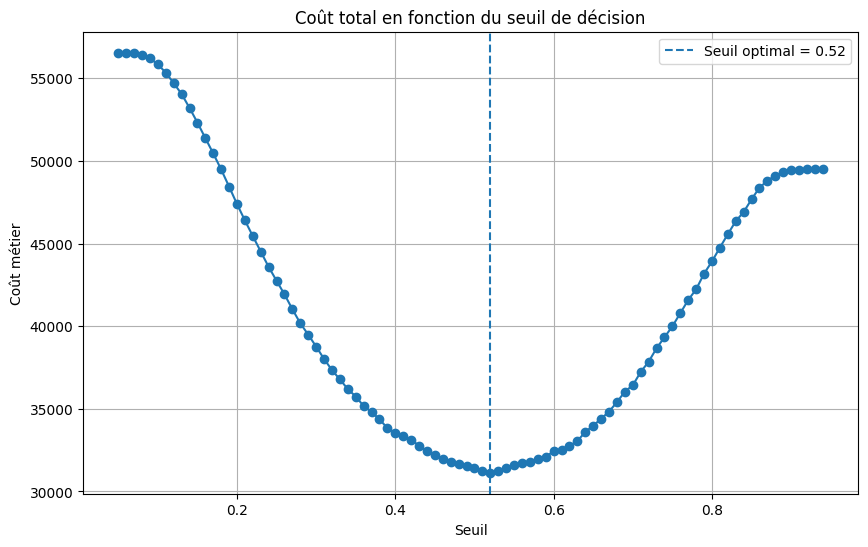

In [94]:
plt.figure(figsize=(10,6))

plt.plot(
    cost_df["threshold"],
    cost_df["cost"],
    marker="o"
)

plt.axvline(
    x=0.52,
    linestyle="--",
    label="Seuil optimal = 0.52"
)

plt.title("Coût total en fonction du seuil de décision")
plt.xlabel("Seuil")
plt.ylabel("Coût métier")
plt.legend()
plt.grid(True)

plt.show()

In [95]:
# Maintenant ajustons notre seuil de décision à 0.52 et évaluons les métriques finales
optimal_threshold = 0.52

In [96]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

y_pred_final = (y_proba >= 0.52).astype(int)

print("Confusion Matrix")
print(confusion_matrix(y_val, y_pred_final))

print("\nClassification Report")
print(classification_report(y_val, y_pred_final))

print("\nMetrics")

print(
    "Accuracy :",
    accuracy_score(y_val, y_pred_final)
)

print(
    "Precision :",
    precision_score(y_val, y_pred_final)
)

print(
    "Recall :",
    recall_score(y_val, y_pred_final)
)

print(
    "F1 Score :",
    f1_score(y_val, y_pred_final)
)

print(
    "ROC AUC :",
    roc_auc_score(y_val, y_proba)
)

Confusion Matrix
[[41960 14594]
 [ 1654  3295]]

Classification Report
              precision    recall  f1-score   support

         0.0       0.96      0.74      0.84     56554
         1.0       0.18      0.67      0.29      4949

    accuracy                           0.74     61503
   macro avg       0.57      0.70      0.56     61503
weighted avg       0.90      0.74      0.79     61503


Metrics
Accuracy : 0.7358177649870739
Precision : 0.18419140253787245
Recall : 0.6657910689028087
F1 Score : 0.28855416411244417
ROC AUC : 0.7724588482616046


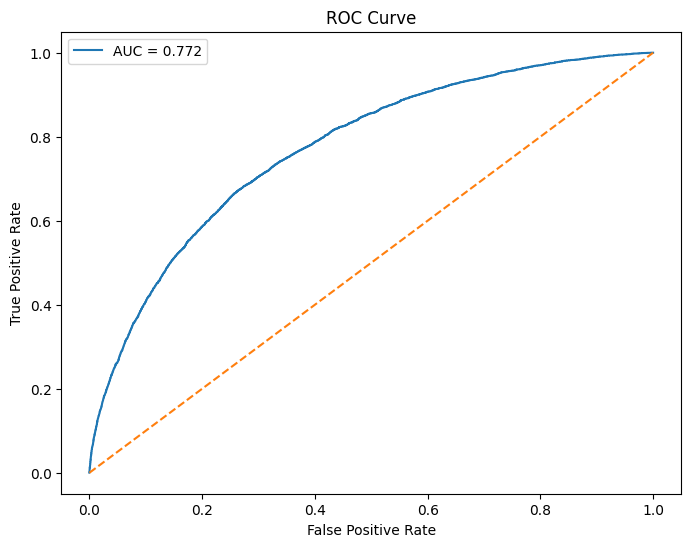

In [98]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(
    y_val,
    y_proba
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc_score(y_val,y_proba):.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    "--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

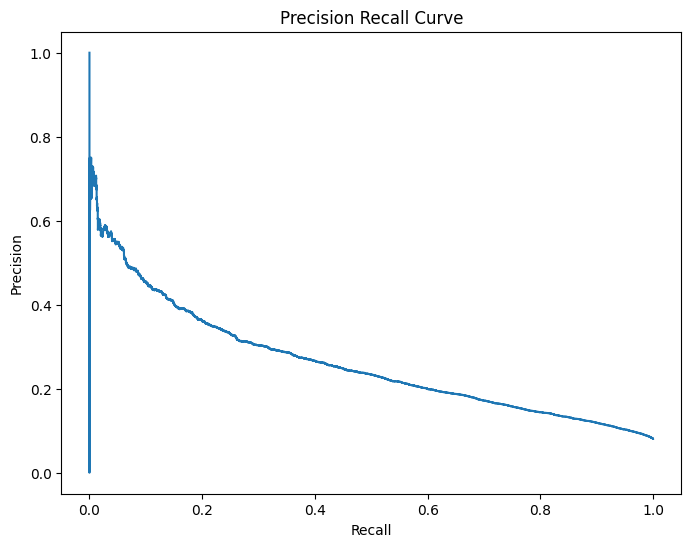

In [99]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(
    y_val,
    y_proba
)

plt.figure(figsize=(8,6))

plt.plot(
    recall,
    precision
)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision Recall Curve")

plt.show()

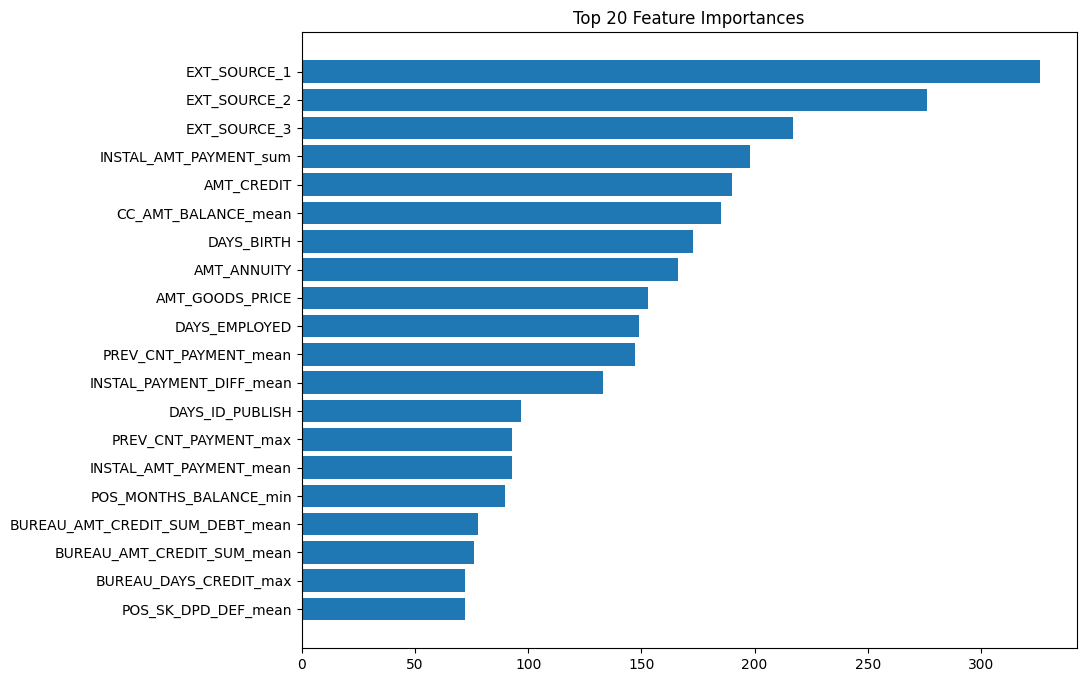

In [100]:
## Visualisons le resultat
# Affichons la feature importance
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
)

feature_importance.head(20)
plt.figure(figsize=(10,8))

plt.barh(
    feature_importance["feature"][:20],
    feature_importance["importance"][:20]
)

plt.gca().invert_yaxis()

plt.title("Top 20 Feature Importances")

plt.show()

In [102]:

# Feature importance locale
client_id = 15
shap.force_plot(
    explainer.expected_value,
    shap_values[client_id],
    X_train.iloc[client_id]
)


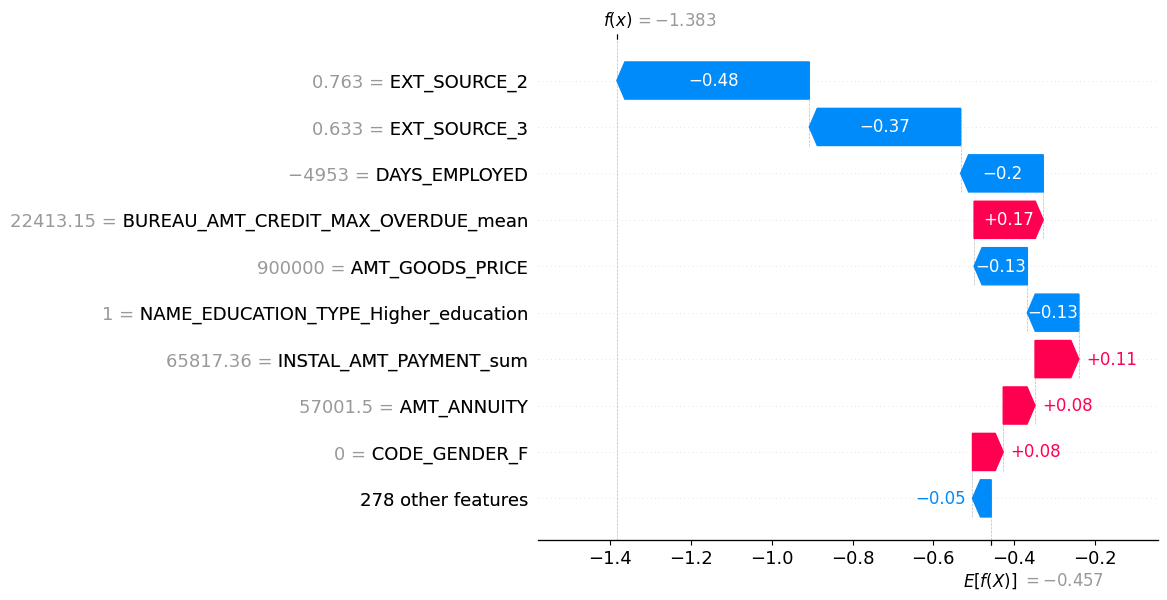

In [103]:
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[client_id],
        base_values=explainer.expected_value,
        data=X_train.iloc[client_id],
        feature_names=X_train.columns
    )
)

c:\Users\El. OURY BALDE\Documents\P6\.venv\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


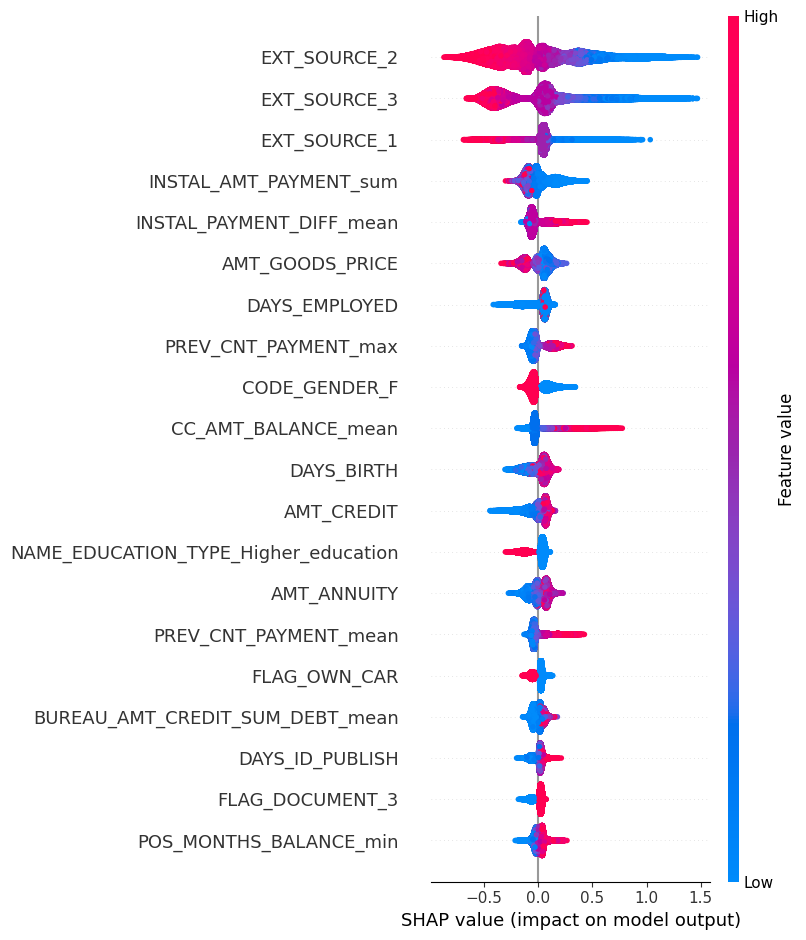

In [101]:
import shap

explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_train)
shap.summary_plot(shap_values, X_train)

In [ ]:
## Réentraînons le modèle avec les features importantes
data 

,feature,importance
30,EXT_SOURCE_1,326
31,EXT_SOURCE_2,276
32,EXT_SOURCE_3,217
139,INSTAL_AMT_PAYMENT_sum,198
5,AMT_CREDIT,190
...,...,...
3,CNT_CHILDREN,0
283,WALLSMATERIAL_MODE_Stone__brick,0
284,WALLSMATERIAL_MODE_Wooden,0
2,FLAG_OWN_REALTY,0


['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'INSTAL_AMT_PAYMENT_sum', 'AMT_CREDIT', 'CC_AMT_BALANCE_mean', 'DAYS_BIRTH', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'DAYS_EMPLOYED', 'PREV_CNT_PAYMENT_mean', 'INSTAL_PAYMENT_DIFF_mean', 'DAYS_ID_PUBLISH', 'PREV_CNT_PAYMENT_max', 'INSTAL_AMT_PAYMENT_mean', 'POS_MONTHS_BALANCE_min', 'BUREAU_AMT_CREDIT_SUM_DEBT_mean', 'BUREAU_AMT_CREDIT_SUM_mean', 'BUREAU_DAYS_CREDIT_max', 'POS_SK_DPD_DEF_mean']


In [71]:
data = train_df.copy()

In [84]:
data = data[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'INSTAL_AMT_PAYMENT_sum', 'AMT_CREDIT', 'CC_AMT_BALANCE_mean', 'DAYS_BIRTH', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'DAYS_EMPLOYED', 'PREV_CNT_PAYMENT_mean', 'INSTAL_PAYMENT_DIFF_mean', 'DAYS_ID_PUBLISH', 'PREV_CNT_PAYMENT_max', 'INSTAL_AMT_PAYMENT_mean', 'POS_MONTHS_BALANCE_min', 'BUREAU_AMT_CREDIT_SUM_DEBT_mean', 'BUREAU_AMT_CREDIT_SUM_mean', 'BUREAU_DAYS_CREDIT_max', 'POS_SK_DPD_DEF_mean','TARGET']]

In [85]:
data.columns

Index(['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
       'INSTAL_AMT_PAYMENT_sum', 'AMT_CREDIT', 'CC_AMT_BALANCE_mean',
       'DAYS_BIRTH', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'DAYS_EMPLOYED',
       'PREV_CNT_PAYMENT_mean', 'INSTAL_PAYMENT_DIFF_mean', 'DAYS_ID_PUBLISH',
       'PREV_CNT_PAYMENT_max', 'INSTAL_AMT_PAYMENT_mean',
       'POS_MONTHS_BALANCE_min', 'BUREAU_AMT_CREDIT_SUM_DEBT_mean',
       'BUREAU_AMT_CREDIT_SUM_mean', 'BUREAU_DAYS_CREDIT_max',
       'POS_SK_DPD_DEF_mean', 'TARGET'],
      dtype='str')

In [86]:
X = data.drop('TARGET', axis=1)

In [87]:
X.columns

Index(['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
       'INSTAL_AMT_PAYMENT_sum', 'AMT_CREDIT', 'CC_AMT_BALANCE_mean',
       'DAYS_BIRTH', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'DAYS_EMPLOYED',
       'PREV_CNT_PAYMENT_mean', 'INSTAL_PAYMENT_DIFF_mean', 'DAYS_ID_PUBLISH',
       'PREV_CNT_PAYMENT_max', 'INSTAL_AMT_PAYMENT_mean',
       'POS_MONTHS_BALANCE_min', 'BUREAU_AMT_CREDIT_SUM_DEBT_mean',
       'BUREAU_AMT_CREDIT_SUM_mean', 'BUREAU_DAYS_CREDIT_max',
       'POS_SK_DPD_DEF_mean'],
      dtype='str')

In [88]:
y = data['TARGET']

In [75]:
y.value_counts()

TARGET
0.0    282686
1.0     24825
Name: count, dtype: int64

In [89]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify= y
)

In [90]:
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score
)

# Modèle
lgm = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=50,
    max_depth=10,
    class_weight="balanced",
    random_state=42
)

# Training
lgm.fit(X_train, y_train)

# Prediction
y_pred = lgm.predict(X_test)
y_proba = lgm.predict_proba(X_test)[:, 1]

# Evaluation
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision :", precision_score(y_test, y_pred))
print("Recall :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC :", roc_auc_score(y_test, y_proba))

[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.015129 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4660
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
Accuracy : 0.7288587548574866
Precision : 0.17899237980373883
Recall : 0.6576032225579054
F1 Score : 0.28139274325605446
ROC AUC : 0.7684372339013086


In [127]:
# Enregistrons le modèle pour une utilisation future
import joblib
joblib.dump(lgm, "lgbm_credit_model.pkl")

['lgbm_credit_model.pkl']

In [92]:
data.to_csv('credit_accord.csv', index=False)

In [95]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 20 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   EXT_SOURCE_1                     307511 non-null  float64
 1   EXT_SOURCE_2                     307511 non-null  float64
 2   EXT_SOURCE_3                     307511 non-null  float64
 3   INSTAL_AMT_PAYMENT_sum           307511 non-null  float64
 4   AMT_CREDIT                       307511 non-null  float64
 5   CC_AMT_BALANCE_mean              307511 non-null  float64
 6   DAYS_BIRTH                       307511 non-null  float64
 7   AMT_ANNUITY                      307511 non-null  float64
 8   AMT_GOODS_PRICE                  307511 non-null  float64
 9   DAYS_EMPLOYED                    307511 non-null  float64
 10  PREV_CNT_PAYMENT_mean            307511 non-null  float64
 11  INSTAL_PAYMENT_DIFF_mean         307511 non-null  float64
 12  DAYS_ID_PUBLI

0         0.262949
1         0.622246
2         0.555912
3         0.650442
4         0.322738
            ...   
307506    0.681632
307507    0.115992
307508    0.535722
307509    0.514163
307510    0.708569
Name: EXT_SOURCE_2, Length: 307511, dtype: float64

In [83]:
df.to_csv('Credit Accord.csv', index = False)

AttributeError: 'Index' object has no attribute 'to_csv'